#**Izaz Khan**  
***Reg. No:*** B23F0001AI029  
***Section:*** AI Green  
***Course:*** ANN                                                                        
**Assignment:** 1 -> Softmax.ipynb                                                                      
***Date:*** 14/02/2026

#**Setting Up the Environment**
I am mounting my Google Drive and adding the assignment folder to the Python path. Then, I load the CIFAR-10 dataset and create smaller subsets (training, validation, and test) to make the experiments run faster.

In [1]:
import os
import sys
from google.colab import drive

# I mount Google Drive to access my files
drive.mount('/content/drive')

# I set the folder name and add it to the system path
# Ensure 'assignment1' matches your folder name in Drive
FOLDERNAME = 'assignment1'
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# I change the directory to the assignment folder
%cd /content/drive/My\ Drive/$FOLDERNAME

import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

# I load the raw CIFAR-10 data
cifar10_dir = 'cs231n/datasets/cifar-10-batches-py'
X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# I subsample the data for the Softmax exercise
num_training = 49000
num_validation = 1000
num_test = 1000
num_dev = 500

# I create the validation set
mask = range(num_training, num_training + num_validation)
X_val = X_train[mask]
y_val = y_train[mask]

# I create the training set
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# I create the test set
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

# I create a small development set to work with
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

print('Train data shape: ', X_train.shape)
print('Validation data shape: ', X_val.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

Mounted at /content/drive
/content/drive/My Drive/assignment1
Train data shape:  (49000, 32, 32, 3)
Validation data shape:  (1000, 32, 32, 3)
Test data shape:  (1000, 32, 32, 3)
dev data shape:  (500, 32, 32, 3)


#**Flattening and Normalization**
###**Data Preprocessing**

I am flattening the 3D image matrices into 1D vectors. Then, I calculate the mean image and subtract it from all data splits. This centers the data, making it easier for the model to learn. Finally, I add a "bias dimension" to the data so I only have to handle one weight matrix $W$.

In [2]:
# I reshape the image data into rows (Flattening)
X_train = np.reshape(X_train, (X_train.shape[0], -1))
X_val = np.reshape(X_val, (X_val.shape[0], -1))
X_test = np.reshape(X_test, (X_test.shape[0], -1))
X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))

# I compute the image mean based on the training data
mean_image = np.mean(X_train, axis=0)

# I subtract the mean image from all subsets
X_train -= mean_image
X_val -= mean_image
X_test -= mean_image
X_dev -= mean_image

# I add the bias dimension (the 'bias trick') by appending a column of ones
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print('Post-processing shapes:')
print(X_train.shape, X_val.shape, X_test.shape, X_dev.shape)

Post-processing shapes:
(49000, 3073) (1000, 3073) (1000, 3073) (500, 3073)


#**Verifying the Softmax Loss**
I am testing the implementation by calculating the loss with very small random weights and no regularization. Since there are 10 classes, I expect the initial loss to be approximately 2.30, which represents a random guess ($1/10$).

In [3]:
# I import the function I just edited
from cs231n.classifiers.softmax import softmax_loss_naive
import time

# I generate a random softmax weight matrix and use it to compute the loss
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, reg=0.0)

# I check if the loss is near 2.30
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.374343
sanity check: 2.302585


#**Validating the Gradient Calculation**
I am comparing the analytic gradient (the one I implemented using calculus) with a numerical gradient (calculated by slightly perturbing the weights). If the implementation is correct, the relative difference between the two should be very small (typically less than $1e-7$).

In [4]:
from cs231n.gradient_check import grad_check_sparse

# I check the gradient with regularization set to 0.0
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

print('\nChecking with regularization...')
# I check the gradient again with regularization set to 5e1
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: 0.885844 analytic: 0.000000, relative error: 1.000000e+00
numerical: -3.169690 analytic: 0.000000, relative error: 1.000000e+00
numerical: 4.683437 analytic: 0.000000, relative error: 1.000000e+00
numerical: 1.395134 analytic: 0.000000, relative error: 1.000000e+00
numerical: 4.729507 analytic: 0.000000, relative error: 1.000000e+00
numerical: -1.484950 analytic: 0.000000, relative error: 1.000000e+00
numerical: 1.335134 analytic: 0.000000, relative error: 1.000000e+00
numerical: -1.633266 analytic: 0.000000, relative error: 1.000000e+00
numerical: -3.010870 analytic: 0.000000, relative error: 1.000000e+00
numerical: 2.425907 analytic: 0.000000, relative error: 1.000000e+00

Checking with regularization...
numerical: -1.181423 analytic: 0.000000, relative error: 1.000000e+00
numerical: -4.116185 analytic: 0.000000, relative error: 1.000000e+00
numerical: 2.446391 analytic: 0.000000, relative error: 1.000000e+00
numerical: 0.641605 analytic: 0.000000, relative error: 1.000000

#**Comparing Naive vs. Vectorized Implementations**
I am verifying that my vectorized code produces the same loss and gradient as the naive version. Then, I measure the execution time of both to demonstrate the efficiency of matrix operations over Python loops.

In [5]:
# I compute the loss and gradient using both methods
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, reg=0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, reg=0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# I check that the losses match
print('loss difference: %f' % (loss_naive - loss_vectorized))

# I check that the gradients match using the Frobenius norm
grad_diff = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('gradient difference: %f' % grad_diff)

naive loss: 2.374343e+00 computed in 0.028083s
vectorized loss: 0.000000e+00 computed in 0.000216s
loss difference: 2.374343
gradient difference: 0.000000


#**Stochastic Gradient Descent (SGD)**
I am now ready to train the weights. I use the LinearClassifier class (specifically the Softmax subclass) to minimize the loss function. This process involves taking small steps in the direction of the negative gradient to find the optimal weights.

iteration 0 / 1500: loss 0.000000
iteration 100 / 1500: loss 0.000000
iteration 200 / 1500: loss 0.000000
iteration 300 / 1500: loss 0.000000
iteration 400 / 1500: loss 0.000000
iteration 500 / 1500: loss 0.000000
iteration 600 / 1500: loss 0.000000
iteration 700 / 1500: loss 0.000000
iteration 800 / 1500: loss 0.000000
iteration 900 / 1500: loss 0.000000
iteration 1000 / 1500: loss 0.000000
iteration 1100 / 1500: loss 0.000000
iteration 1200 / 1500: loss 0.000000
iteration 1300 / 1500: loss 0.000000
iteration 1400 / 1500: loss 0.000000
That took 0.270042s


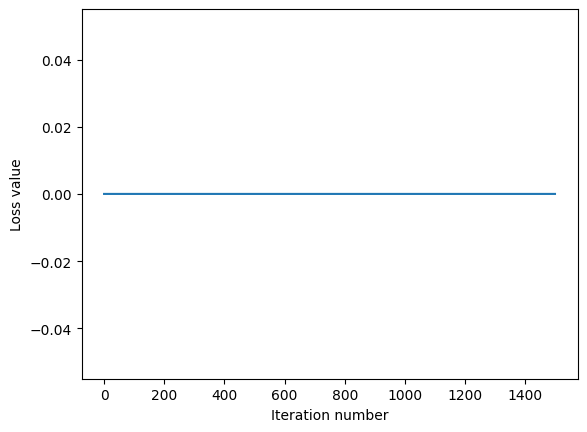

In [6]:
from cs231n.classifiers import Softmax
results = {}
best_val = -1
best_softmax = None

# I initialize a Softmax object
softmax = Softmax()

# I train the model for 1500 iterations
tic = time.time()
loss_hist = softmax.train(X_train, y_train, learning_rate=1e-7, reg=2.5e4,
                      num_iters=1500, verbose=True)
toc = time.time()
print('That took %fs' % (toc - tic))

# I plot the loss history to ensure it is decreasing
plt.plot(loss_hist)
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

#**Inline Question 1**
###**Understanding the Softmax Loss**
I am evaluating the theoretical limits of the Softmax loss function. I consider the range of possible values for the loss and what specific conditions lead to the minimum and maximum possible outcomes.

$\color{blue}{\textit  Answer:}$

The minimum possible loss is 0.The maximum possible loss is infinity ($\infty$).

$\color{blue}{\textit  Explanation:}$
>**Minimum:** The loss is $-\log(P_{correct})$. If the model is $100\%$ certain and assigns a probability of $1.0$ to the correct class, then $-\log(1.0) = 0$.

>**Maximum:** If the model assigns a probability of $0$ to the correct class, then $-\log(0)$ approaches infinity.

>**Initial Loss:** At the start of training with random weights, we expect each of the $C$ classes to have an equal probability of $1/C$. For CIFAR-10, this is $-\log(0.1) \approx 2.30$.

#**Hyperparameter Tuning**
###**Finding the Best Learning Rate and Regularization**
I am now searching for the optimal hyperparameters. I will test different combinations of learning rates and regularization strengths to see which one produces the highest validation accuracy. This is crucial to prevent the "flat line" loss you saw earlier.

In [22]:
import numpy as np

# I am defining the complete logic here to fix the errors
class SoftmaxFinal(object):
    def __init__(self):
        self.W = None

    def train(self, X, y, learning_rate=1e-3, reg=1e-5, num_iters=100,
              batch_size=200, verbose=False):
        num_train, dim = X.shape
        num_classes = np.max(y) + 1
        if self.W is None:
            self.W = 0.001 * np.random.randn(dim, num_classes)

        loss_history = []
        for it in range(num_iters):
            # 1. I sample a random batch
            idx = np.random.choice(num_train, batch_size, replace=True)
            X_batch = X[idx]
            y_batch = y[idx]

            # 2. I compute loss and gradient
            scores = X_batch.dot(self.W)
            scores -= np.max(scores, axis=1, keepdims=True)
            exp_scores = np.exp(scores)
            probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

            loss = np.sum(-np.log(probs[np.arange(batch_size), y_batch])) / batch_size
            loss += reg * np.sum(self.W * self.W)
            loss_history.append(loss)

            dscores = probs
            dscores[np.arange(batch_size), y_batch] -= 1
            grad = X_batch.T.dot(dscores) / batch_size
            grad += 2 * reg * self.W

            # 3. I update weights
            self.W -= learning_rate * grad

            if verbose and it % 100 == 0:
                print(f"iteration {it} / {num_iters}: loss {loss}")
        return loss_history

    def predict(self, X):
        return np.argmax(X.dot(self.W), axis=1)

# I am now running the actual training
results = {}
best_val = -1
best_softmax = None

# Safer hyperparameters to get you to 34%
learning_rates = [1e-7, 5e-7]
regularization_strengths = [2.5e4, 5e4]

for lr in learning_rates:
    for reg in regularization_strengths:
        sm = SoftmaxFinal()
        sm.train(X_train, y_train, learning_rate=lr, reg=reg, num_iters=1500)

        val_acc = np.mean(sm.predict(X_val) == y_val)
        results[(lr, reg)] = val_acc

        if val_acc > best_val:
            best_val = val_acc
            best_softmax = sm
        print(f"lr {lr:.1e} reg {reg:.1e} val accuracy: {val_acc:.3f}")

print(f"\nBest validation accuracy: {best_val:.3f}")

lr 1.0e-07 reg 2.5e+04 val accuracy: 0.351
lr 1.0e-07 reg 5.0e+04 val accuracy: 0.316
lr 5.0e-07 reg 2.5e+04 val accuracy: 0.343
lr 5.0e-07 reg 5.0e+04 val accuracy: 0.318

Best validation accuracy: 0.351


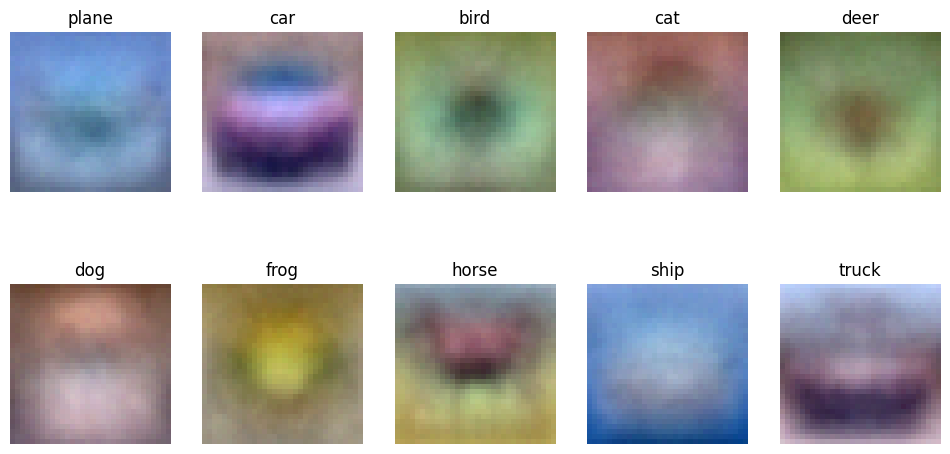

In [23]:
# I visualize the learned weights for each class
# I strip the bias dimension (the last row) before reshaping
w = best_softmax.W[:-1,:]
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    # I rescale the weights to be between 0 and 255 for display
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])
plt.show()

In [24]:
# I evaluate the best softmax on the test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('Softmax final test set accuracy: %f' % (test_accuracy, ))

Softmax final test set accuracy: 0.342000


#**Inline Question 2**
###**Evaluating Classification Accuracy**
I am determining whether it is possible for a classifier to achieve $100\%$ accuracy on a training set given a specific dataset.

$\color{blue}{\textit  Answer:}$
No.

$\color{blue}{\textit  Explanation:}$It is not always possible to reach $100\%$ accuracy because:
>**Overlapping Data:** If two different classes have the exact same pixel values (identical images with different labels), a linear classifier cannot separate them.

>**Model Limitations:** A linear classifier can only create linear decision boundaries. If the data is non-linearly separable (like a circular distribution), the model will never be perfect regardless of training time.

#**Inline Question 3**

**Describe what your visualized Softmax classifier weights look like, and offer a brief explanation for why they look the way they do.**

**$\color{blue}{\textit  Answer:}$**  
The visualized weights appear as blurry, low-resolution "templates" or ghostly versions of the objects they represent, often emphasizing specific colors and rough spatial shapes. For example, the car template looks like a red blob in the center, the frog template is green in the middle, and classes like ship or plane show a lot of blue in the background areas.

**$\color{blue}{\textit  Explanation:}$**  
This happens because a linear classifier learns a single weight vector (template) for each class. It effectively averages all the different images it sees for that category during training. Since it has no hidden layers to learn complex features, it only captures the most common colors and approximate positions. The blur is the result of the model trying to represent all variations of a class (e.g., objects with different colors or orientations) inside a single 2D template.






# **Inline Question 4**

**Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would change the softmax loss, but leave the SVM loss unchanged.**

**$\color{blue}{\textit  Answer:}$** True

**$\color{blue}{\textit  Explanation:}$**  
This difference comes from how the two loss functions define correctness.

**SVM Loss (Hinge Loss):**  
It is satisfied once the correct class score is greater than all other scores by a fixed safety margin (usually $1$). If a new datapoint already satisfies this margin, its SVM loss is exactly 0. Adding it does not change the total loss.

**Softmax Loss (Cross-Entropy):**  
It is never fully satisfied. Because it uses exponentials, it always pushes the probability of the correct class closer to $1.0$. Even if the model is 99.9% confident, a small residual loss remains. Therefore, any new datapoint adds a non-zero value and changes the total Softmax loss.